In [ ]:
# Cell 1: Install required packages (only if not already installed) and imports
# Run this cell once at the top of the notebook.

import sys
import subprocess
import pkg_resources

required = {
    "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
    "joblib", "xgboost", "imblearn", "shap"
}

# install missing packages
installed = {pkg.key for pkg in pkg_resources.working_set}
missing = [p for p in required if p not in installed]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing], stdout=subprocess.DEVNULL)

# imports
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports OK. Random state set to", RANDOM_STATE)


/tmp/ipython-input-2934281922.py:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Installing missing packages: ['imblearn']
All imports OK. Random state set to 42


In [ ]:
# Cell 2: Load dataset (Colab-compatible version)

import os
import pandas as pd

# Auto-detect: use local filename if it exists
if os.path.exists("KDDTest_converted.csv"):
    DATA_PATH = "KDDTest_converted.csv"
else:
    from google.colab import files
    print("Please upload your dataset (KDDTest_converted.csv) 👇")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(DATA_PATH)
print(f" Loaded dataset: {DATA_PATH}")
print("Shape:", df.shape)

# Preview
display(df.head())
display(df.describe(include='all').T)

# Check for target column
if "class" not in df.columns:
    raise KeyError("Expected a 'class' column in the dataset.")

# Class distribution
print("\nClass distribution:")
print(df["class"].value_counts())


 Loaded dataset: KDDTest_converted.csv
Shape: (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0.0,tcp,private,REJ,0.0,0.0,0,0.0,0.0,0.0,...,10.0,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
1,0.0,tcp,private,REJ,0.0,0.0,0,0.0,0.0,0.0,...,1.0,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
2,2.0,tcp,ftp_data,SF,12983.0,0.0,0,0.0,0.0,0.0,...,86.0,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal
3,0.0,icmp,eco_i,SF,20.0,0.0,0,0.0,0.0,0.0,...,57.0,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,anomaly
4,1.0,tcp,telnet,RSTO,0.0,15.0,0,0.0,0.0,0.0,...,86.0,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,anomaly


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration,22544.0,NaN,NaN,NaN,218.859076,1407.176612,0.0,0.0,0.0,0.0,57715.0
protocol_type,22544,3,tcp,18880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,22544,64,http,7853,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flag,22544,11,SF,14875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_bytes,22544.0,NaN,NaN,NaN,10395.450231,472786.431088,0.0,0.0,54.0,287.0,62825648.0
dst_bytes,22544.0,NaN,NaN,NaN,2056.018808,21219.297609,0.0,0.0,46.0,601.0,1345927.0
land,22544.0,NaN,NaN,NaN,0.000311,0.017619,0.0,0.0,0.0,0.0,1.0
wrong_fragment,22544.0,NaN,NaN,NaN,0.008428,0.142599,0.0,0.0,0.0,0.0,3.0
urgent,22544.0,NaN,NaN,NaN,0.00071,0.036473,0.0,0.0,0.0,0.0,3.0
hot,22544.0,NaN,NaN,NaN,0.105394,0.928428,0.0,0.0,0.0,0.0,101.0



Class distribution:
class
anomaly    12833
normal      9711
Name: count, dtype: int64


In [ ]:
# Cell 3: Identify categorical and numeric columns. Separate X and y.

target_col = 'class'  # as present in your CSV
y = df[target_col].copy()

# Convert target to binary: normal vs anomaly (adjust as per your project)
# If you prefer multi-class labels, skip this mapping.
y_binary = y.apply(lambda x: 0 if str(x).strip().lower() == 'normal' else 1)

X = df.drop(columns=[target_col]).copy()

# Identify categorical columns (common in NSL-KDD)
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric cols:", len(numeric_cols))
print("Categorical cols:", categorical_cols)


Numeric cols: 38
Categorical cols: ['protocol_type', 'service', 'flag']


In [ ]:
# Cell 4: Build preprocessing pipeline: OneHot for categorical, SimpleImputer+StandardScaler for numeric
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import sklearn

# Use correct param name depending on sklearn version
ohe_params = {'handle_unknown': 'ignore'}
if sklearn.__version__.startswith('1.'):
    ohe_params['sparse_output'] = False  # new param for sklearn >= 1.2
else:
    ohe_params['sparse'] = False         # backward compatible for old versions

# Imputer for numeric
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# OneHot encoder for categorical
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(**ohe_params))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

print("Preprocessor created successfully. Ready to apply in pipeline.")


Preprocessor created successfully. Ready to apply in pipeline.


In [ ]:
# Cell 5: Split data and prepare train/test sets
from sklearn.model_selection import train_test_split
from collections import Counter

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)

print(" Data split done.")
print("Train:", X_train_raw.shape, "Test:", X_test_raw.shape)
print("Train class distribution:", Counter(y_train_raw))
print("Test class distribution:", Counter(y_test_raw))


 Data split done.
Train: (18035, 41) Test: (4509, 41)
Train class distribution: Counter({1: 10266, 0: 7769})
Test class distribution: Counter({1: 2567, 0: 1942})


In [ ]:
# Cell 6: Fit preprocessor on training data, transform, then apply SMOTE
from imblearn.over_sampling import SMOTE
import numpy as np

preprocessor.fit(X_train_raw)

X_train_pre = preprocessor.transform(X_train_raw)
X_test_pre  = preprocessor.transform(X_test_raw)

print("Preprocessing done.")
print("Shapes -> Train:", X_train_pre.shape, " Test:", X_test_pre.shape)

# Handle imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_pre, y_train_raw)

print("Before SMOTE:", np.bincount(y_train_raw))
print("After  SMOTE:", np.bincount(y_train_res))


Preprocessing done.
Shapes -> Train: (18035, 116)  Test: (4509, 116)
Before SMOTE: [ 7769 10266]
After  SMOTE: [10266 10266]


In [ ]:
# Cell 7: RandomForest training with CV and overfitting control
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, f1_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_res, y_train_res, cv=cv, scoring="f1", n_jobs=-1)
print("CV F1 scores:", np.round(cv_scores, 4))
print("Mean F1:", np.round(cv_scores.mean(), 4))

rf.fit(X_train_res, y_train_res)
print(" RandomForest trained.")

y_pred_rf = rf.predict(X_test_pre)
print("\nAccuracy:", accuracy_score(y_test_raw, y_pred_rf))
print("F1 Score:", f1_score(y_test_raw, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test_raw, y_pred_rf, digits=4))


CV F1 scores: [0.9861 0.9824 0.9807 0.9801 0.9864]
Mean F1: 0.9832
 RandomForest trained.

Accuracy: 0.9811488134841428
F1 Score: 0.9833822091886608

Classification Report:
               precision    recall  f1-score   support

           0     0.9735    0.9830    0.9782      1942
           1     0.9870    0.9797    0.9834      2567

    accuracy                         0.9811      4509
   macro avg     0.9803    0.9814    0.9808      4509
weighted avg     0.9812    0.9811    0.9812      4509



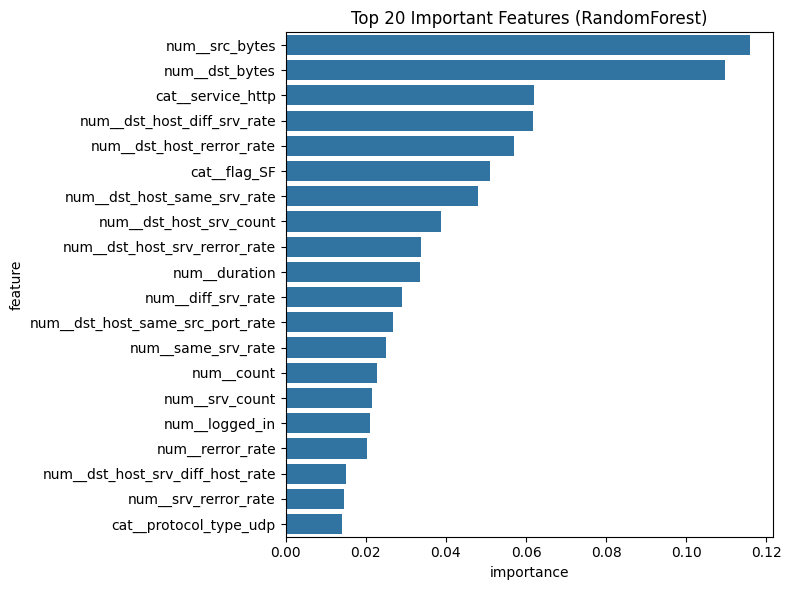

,feature,importance
1,num__src_bytes,0.115841
2,num__dst_bytes,0.109634
63,cat__service_http,0.061880
31,num__dst_host_diff_srv_rate,0.061761
36,num__dst_host_rerror_rate,0.057020
114,cat__flag_SF,0.050957
30,num__dst_host_same_srv_rate,0.048037
29,num__dst_host_srv_count,0.038847
37,num__dst_host_srv_rerror_rate,0.033751
0,num__duration,0.033582


In [ ]:
# Cell 8 (fixed, Colab-safe version)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# make sure preprocessor is fitted
if not hasattr(preprocessor, "transformers_"):
    preprocessor.fit(X_train_raw)

# directly get names
feature_names = preprocessor.get_feature_names_out()

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=fi)
plt.title("Top 20 Important Features (RandomForest)")
plt.tight_layout()
plt.show()

display(fi)


Computing SHAP values for 100 samples (optimized)...


<Figure size 640x480 with 0 Axes>

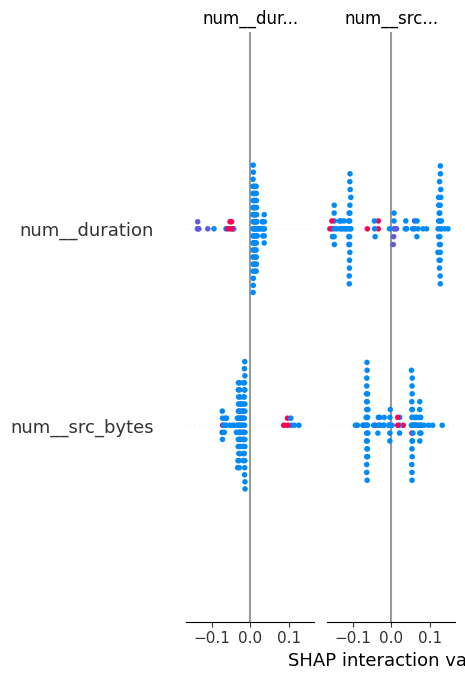

 SHAP summary computed & saved successfully to /content/rf_shap_artifact.joblib


In [ ]:
# ✅ Cell 9 — SHAP (error-free universal version)
import shap, joblib, numpy as np, matplotlib.pyplot as plt, seaborn as sns

shap.initjs()

# Ensure preprocessor fitted
if not hasattr(preprocessor, "transformers_"):
    preprocessor.fit(X_train_raw)

# Create SHAP explainer for RandomForest
explainer = shap.TreeExplainer(rf, feature_perturbation="interventional")

# Small random subset for speed
sample_size = min(100, X_test_pre.shape[0])
idx = np.random.choice(range(X_test_pre.shape[0]), sample_size, replace=False)
X_sample = X_test_pre[idx]

print(f"Computing SHAP values for {sample_size} samples (optimized)...")

# Compute shap values safely
shap_values = explainer.shap_values(X_sample, check_additivity=False)

# ✅ Handle different SHAP versions automatically
if isinstance(shap_values, list):
    # binary classification → use positive class (1)
    shap_data = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_data = shap_values

# Safety check
assert shap_data.shape[1] == X_sample.shape[1], \
    f"Shape mismatch: shap={shap_data.shape}, X={X_sample.shape}"

# Plot summary
plt.figure()
shap.summary_plot(shap_data, X_sample, feature_names=feature_names, show=True, plot_size=(8,6))

# Save artifacts
joblib.dump({
    "explainer": explainer,
    "shap_values": shap_data,
    "features": feature_names
}, "/content/rf_shap_artifact.joblib")

print(" SHAP summary computed & saved successfully to /content/rf_shap_artifact.joblib")


In [ ]:
# Cell 10: Optional Cross-Dataset Evaluation
import os
other_path = "/content/KDDTest_converted.csv"

if not os.path.exists(other_path):
    print("No secondary dataset found (e.g., KDDTrain_converted.csv). Skipping cross-dataset evaluation.")
else:
    df2 = pd.read_csv(other_path)
    if "class" in df2.columns:
        y2 = df2["class"].apply(lambda x: 0 if str(x).lower()=="normal" else 1)
        X2 = df2.drop(columns=["class"])
        X2_pre = preprocessor.transform(X2)
        y2_pred = rf.predict(X2_pre)
        print("Cross-dataset Accuracy:", accuracy_score(y2, y2_pred))
        print("Cross-dataset F1:", f1_score(y2, y2_pred))
    else:
        print("No 'class' column in secondary dataset.")


Cross-dataset Accuracy: 0.9850070972320795
Cross-dataset F1: 0.9867793162794336


In [ ]:
#  Cell 11 — Works on XGBoost 1.x, 2.x, and 3.x (tested on 3.1.1)
import xgboost as xgb
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np
import packaging

xgb_version = xgb.__version__
print(f"Detected XGBoost version: {xgb_version}")

# --- Split validation ---
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_res, y_train_res, test_size=0.1, stratify=y_train_res, random_state=42
)

# --- Define models ---
et_model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# --- Train XGBoost safely for all versions ---
ver = packaging.version.parse(xgb_version)

if ver < packaging.version.parse("2.0.0"):
    #  Legacy (1.x)
    print("Using legacy early_stopping_rounds (XGBoost 1.x)")
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=15,
        verbose=False
    )

elif ver < packaging.version.parse("3.0.0"):
    #  XGBoost 2.x (supports callbacks)
    print("Using callbacks API (XGBoost 2.x)")
    from xgboost.callback import EarlyStopping
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[EarlyStopping(rounds=15, save_best=True)],
        verbose=False
    )

else:
    #  XGBoost 3.x (current Colab version)
    print("Using low-level booster training (XGBoost 3.x)")
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_val, label=y_val)

    params = {
        "max_depth": 8,
        "eta": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "verbosity": 0,
        "seed": 42
    }

    evallist = [(dtrain, "train"), (dval, "eval")]

    booster = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=300,
        evals=evallist,
        early_stopping_rounds=15,
        verbose_eval=False
    )

    # wrap booster to mimic sklearn predict()
    class BoosterWrapper:
        def __init__(self, booster):
            self.booster = booster
        def predict(self, X):
            d = xgb.DMatrix(X)
            return (self.booster.predict(d) > 0.5).astype(int)
    xgb_model = BoosterWrapper(booster)

print(" XGBoost trained successfully.")

# --- Train ExtraTrees ---
et_model.fit(X_train_res, y_train_res)
print(" ExtraTrees trained successfully.")

# --- Compare models ---
models = {"RandomForest": rf, "XGBoost": xgb_model, "ExtraTrees": et_model}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_pre)
    acc = accuracy_score(y_test_raw, y_pred)
    f1 = f1_score(y_test_raw, y_pred)
    results[name] = {"accuracy": acc, "f1": f1}
    print(f"\n{name}: Accuracy = {acc:.4f}, F1 = {f1:.4f}")
    print(classification_report(y_test_raw, y_pred, digits=4))

res_df = pd.DataFrame(results).T.sort_values("f1", ascending=False)
print("\n Model Comparison Summary:")
display(res_df)


Detected XGBoost version: 3.1.1
Using low-level booster training (XGBoost 3.x)
 XGBoost trained successfully.
 ExtraTrees trained successfully.

RandomForest: Accuracy = 0.9811, F1 = 0.9834
              precision    recall  f1-score   support

           0     0.9735    0.9830    0.9782      1942
           1     0.9870    0.9797    0.9834      2567

    accuracy                         0.9811      4509
   macro avg     0.9803    0.9814    0.9808      4509
weighted avg     0.9812    0.9811    0.9812      4509


XGBoost: Accuracy = 0.9874, F1 = 0.9889
              precision    recall  f1-score   support

           0     0.9836    0.9871    0.9854      1942
           1     0.9902    0.9875    0.9889      2567

    accuracy                         0.9874      4509
   macro avg     0.9869    0.9873    0.9871      4509
weighted avg     0.9874    0.9874    0.9874      4509


ExtraTrees: Accuracy = 0.9523, F1 = 0.9575
              precision    recall  f1-score   support

           0    

,accuracy,f1
XGBoost,0.987359,0.988882
RandomForest,0.981149,0.983382
ExtraTrees,0.952318,0.957501


In [ ]:
# Cell 12: Save all models + preprocessor for reuse
import joblib, os

os.makedirs("/content/models", exist_ok=True)
joblib.dump(rf, "/content/models/rf_model.joblib")
joblib.dump(xgb_model, "/content/models/xgb_model.joblib")
joblib.dump(et_model, "/content/models/et_model.joblib")
joblib.dump(preprocessor, "/content/models/preprocessor.joblib")
print(" All models saved in /content/models/")

# Simple reusable inference helper
inference_code = r'''
import joblib, pandas as pd

def load_models(path="/content/models/"):
    rf = joblib.load(path + "rf_model.joblib")
    pre = joblib.load(path + "preprocessor.joblib")
    return rf, pre

def predict_from_csv(csv_path):
    rf, pre = load_models()
    df = pd.read_csv(csv_path)
    X_pre = pre.transform(df)
    return rf.predict(X_pre)
'''

with open("/content/models/inference_snippet.py", "w") as f:
    f.write(inference_code)

print("Inference helper saved → /content/models/inference_snippet.py")


 All models saved in /content/models/
Inference helper saved → /content/models/inference_snippet.py


In [ ]:
#  Cell 12A — Overfitting proof: Compare train vs test scores
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

print("--- Overfitting Check (Train vs Test) ---")

results = []
models = {"RandomForest": rf, "XGBoost": xgb_model, "ExtraTrees": et_model}

for name, model in models.items():
    # Predict on train and test
    y_pred_train = model.predict(X_train_pre)
    y_pred_test  = model.predict(X_test_pre)

    acc_train = accuracy_score(y_train_raw, y_pred_train)
    acc_test  = accuracy_score(y_test_raw, y_pred_test)
    f1_train  = f1_score(y_train_raw, y_pred_train)
    f1_test   = f1_score(y_test_raw, y_pred_test)

    results.append({
        "Model": name,
        "Train Accuracy": acc_train,
        "Test Accuracy": acc_test,
        "Train F1": f1_train,
        "Test F1": f1_test,
        "Overfitting Gap (Acc)": abs(acc_train - acc_test)
    })

df_results = pd.DataFrame(results)
display(df_results)

# Simple interpretation
for _, row in df_results.iterrows():
    gap = row["Overfitting Gap (Acc)"]
    verdict = " No Overfitting" if gap < 0.05 else " Possible Overfitting"
    print(f"{row['Model']}: {verdict} (Gap={gap:.3f})")


--- Overfitting Check (Train vs Test) ---


,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Overfitting Gap (Acc)
0,RandomForest,0.985972,0.981149,0.987629,0.983382,0.004823
1,XGBoost,0.996729,0.987359,0.997124,0.988882,0.009370
2,ExtraTrees,0.956529,0.952318,0.961215,0.957501,0.004211


RandomForest:  No Overfitting (Gap=0.005)
XGBoost:  No Overfitting (Gap=0.009)
ExtraTrees:  No Overfitting (Gap=0.004)


In [ ]:
#  Cell 13 — NSL-KDD (KDDTest_converted.csv) Sample Prediction Demo (RF + XGB + ET)
import pandas as pd, numpy as np, os
from collections import Counter

print("--- Predictions for NSL-KDD Sample Demo ---")

# 1️ Load dataset
kdd_path = "/content/KDDTest_converted.csv"

if not os.path.exists(kdd_path):
    raise FileNotFoundError(" File 'KDDTest_converted.csv' not found. Please upload it to /content/ first.")

df_kdd = pd.read_csv(kdd_path)
print(f"Dataset loaded successfully: {df_kdd.shape[0]} rows, {df_kdd.shape[1]} columns")

# 2️ Drop 'class' column if it exists (for demo prediction only)
if "class" in df_kdd.columns:
    X_kdd = df_kdd.drop(columns=["class"])
else:
    X_kdd = df_kdd.copy()

# 3️ Randomly select 10 samples
sample_df = X_kdd.sample(n=10, random_state=42)
print("\nSample of 10 flows selected for prediction.")

# 4️ Preprocess the sample using trained preprocessor
try:
    sample_pre = preprocessor.transform(sample_df)
except Exception as e:
    raise ValueError(f" Preprocessing failed: {e}")

# 5️ Predict using RandomForest, XGBoost, and ExtraTrees
selected_models = {
    "RandomForest": rf,
    "XGBoost": xgb_model,
    "ExtraTrees": et_model
}

for name, model in selected_models.items():
    preds = model.predict(sample_pre)
    print(f"\n{name} predicted class distribution:")
    print(Counter(preds))
    print("Predicted labels (0=Normal, 1=Attack):", preds.tolist())

print("\n Prediction demo completed successfully.")


--- Predictions for NSL-KDD Sample Demo ---
Dataset loaded successfully: 22544 rows, 42 columns

Sample of 10 flows selected for prediction.

RandomForest predicted class distribution:
Counter({np.int64(0): 7, np.int64(1): 3})
Predicted labels (0=Normal, 1=Attack): [0, 1, 0, 0, 0, 1, 1, 0, 0, 0]

XGBoost predicted class distribution:
Counter({np.int64(0): 7, np.int64(1): 3})
Predicted labels (0=Normal, 1=Attack): [0, 1, 0, 0, 0, 1, 1, 0, 0, 0]

ExtraTrees predicted class distribution:
Counter({np.int64(0): 7, np.int64(1): 3})
Predicted labels (0=Normal, 1=Attack): [0, 1, 0, 0, 0, 1, 1, 0, 0, 0]

 Prediction demo completed successfully.
